## Projeto do Bootcamp Avanti - Machine Learning

🔹 Projeto 03

📌 Assunto: Classificação de lesões em folhas de feijão

🔗 Dataset original: https://www.kaggle.com/datasets/marquis03/bean-leaf-lesions-classification

🔗 Dataset criado: https://drive.google.com/drive/folders/1VN0zNN7CC1wk6z3ZIcF-S5kGW-par32m?usp=sharing

📌 Link do Projeto: https://github.com/jaimejrs/avanti-bean-leaf-classification


### Participantes:
Cristiane Santos da Cunha

Eric Gabriel Aguiar de Alencar

Fabrício Almeida Santos

Ian Silva Nogueira

Jaime Teixeira de Araújo Júnior

Juliana Gonçalves Câmara

### ATIVIDADE-04-ETAPA-01
#### Objetivo: Apresentar informações do dataset





#### Baixar dataset do Google Drive

In [1]:
!pip install opendatasets
!pip install pandas
!pip install imagehash

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 22.9 MB/s eta 0:00:00


In [2]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [71]:
import os



In [72]:
root_dir = "/content/drive/MyDrive/bean-leaf-lesions-classification"

In [5]:
print("Dataset encontrado:", os.path.exists(root_dir))

if os.path.exists(root_dir):
    print("\nConteúdo:")
    print(os.listdir(root_dir))

Dataset encontrado: True

Conteúdo:
['train.csv', 'classname.txt', 'val', 'val.csv', 'test', 'test.csv', 'train']


In [6]:
# IMPORTAÇÕES
!pip install opencv-python

import pandas as pd
import os
import cv2
import imagehash
import matplotlib.pyplot as plt
%matplotlib inline
import random
import shutil

In [7]:
!ls

drive  sample_data


#### Separação das imagens para treinamento, teste e validação


In [73]:
# estrutura do data set

print(os.listdir("/content/drive/MyDrive/bean-leaf-lesions-classification"))

['train.csv', 'classname.txt', 'val', 'val.csv', 'test', 'test.csv', 'train', 'model.pth']


In [8]:
train_df = pd.read_csv("/content/drive/MyDrive/bean-leaf-lesions-classification/train.csv")

train_df.head()



,image:FILE,category
0,train/healthy/healthy_train.98.jpg,0
1,train/healthy/healthy_train.148.jpg,0
2,train/healthy/healthy_train.306.jpg,0
3,train/healthy/healthy_train.305.jpg,0
4,train/healthy/healthy_train.40.jpg,0


In [9]:
print(train_df.columns)

Index(['image:FILE', 'category'], dtype='object')


In [14]:
# Validação

val_df = pd.read_csv("/content/drive/MyDrive/bean-leaf-lesions-classification/val.csv")

imagens_csv = set(val_df["image:FILE"])
imagens_pasta = set()

val_dir = "/content/drive/MyDrive/bean-leaf-lesions-classification/val"

for classe in os.listdir(val_dir):
    pasta = os.path.join(val_dir, classe)

    if os.path.isdir(pasta):
        for img in os.listdir(pasta):
            imagens_pasta.add(img)

faltando = imagens_csv - imagens_pasta
extras = imagens_pasta - imagens_csv

print(f"Imagens listadas no CSV: {len(imagens_csv)}")
print(f"Imagens encontradas na pasta: {len(imagens_pasta)}")
print(f"Imagens no CSV e ausentes na pasta: {len(faltando)}")
print(f"Imagens na pasta e ausentes no CSV: {len(extras)}")

Imagens listadas no CSV: 133
Imagens encontradas na pasta: 133
Imagens no CSV e ausentes na pasta: 133
Imagens na pasta e ausentes no CSV: 133


In [15]:
# Ler o CSV
train_df = pd.read_csv("/content/drive/MyDrive/bean-leaf-lesions-classification/train.csv")

# Imagens listadas no CSV
imagens_csv = set(train_df["image:FILE"])

# Imagens existentes na pasta
imagens_pasta = set()

train_dir = "/content/drive/MyDrive/bean-leaf-lesions-classification/train"

for classe in os.listdir(train_dir):
    pasta = os.path.join(train_dir, classe)

    if os.path.isdir(pasta):
        for img in os.listdir(pasta):
            imagens_pasta.add(img)

# Comparação
faltando = imagens_csv - imagens_pasta
extras = imagens_pasta - imagens_csv

print(f"Imagens listadas no CSV: {len(imagens_csv)}")
print(f"Imagens encontradas na pasta: {len(imagens_pasta)}")
print(f"Imagens no CSV e ausentes na pasta: {len(faltando)}")
print(f"Imagens na pasta e ausentes no CSV: {len(extras)}")

Imagens listadas no CSV: 1034
Imagens encontradas na pasta: 880
Imagens no CSV e ausentes na pasta: 1034
Imagens na pasta e ausentes no CSV: 880


In [16]:
# Teste

# Pasta de teste
test_dir = "/content/drive/MyDrive/bean-leaf-lesions-classification/test"

# Conjunto para armazenar os nomes das imagens
imagens_teste = set()

# Percorre cada classe
for classe in os.listdir(test_dir):
    pasta = os.path.join(test_dir, classe)

    if os.path.isdir(pasta):
        for img in os.listdir(pasta):
            imagens_teste.add(img)

print(f"Total de imagens de teste: {len(imagens_teste)}")

# Exibe algumas imagens
print("\nPrimeiras 10 imagens:")
for img in list(imagens_teste)[:10]:
    print(img)

Total de imagens de teste: 154

Primeiras 10 imagens:
angular_leaf_spot_train.60.jpg
bean_rust_train.309.jpg
healthy_train.179.jpg
bean_rust_train.127.jpg
bean_rust_train.265.jpg
angular_leaf_spot_train.254.jpg
healthy_train.163.jpg
bean_rust_train.270.jpg
healthy_train.244.jpg
angular_leaf_spot_train.13.jpg


In [17]:
train_dir = "/content/drive/MyDrive/bean-leaf-lesions-classification/train"
validation_dir = "/content/drive/MyDrive/bean-leaf-lesions-classification/val"
test_dir = "/content/drive/MyDrive/bean-leaf-lesions-classification/test"

def contar_imagens(diretorio):
    total = 0

    for classe in os.listdir(diretorio):
        pasta = os.path.join(diretorio, classe)

        if os.path.isdir(pasta):
            total += len(os.listdir(pasta))

    return total

train = contar_imagens(train_dir)
validation = contar_imagens(val_dir)
test = contar_imagens(test_dir)

print(f"Treinamento: {train}")
print(f"Validação: {validation}")
print(f"Teste: {test}")

Treinamento: 880
Validação: 133
Teste: 154


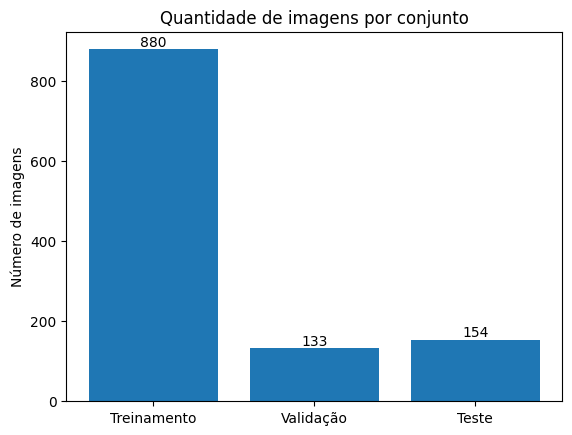

In [18]:
# Gráfico
conjuntos = ["Treinamento", "Validação", "Teste"]
quantidades = [train, validation, test]

ax = plt.bar(conjuntos, quantidades)

plt.title("Quantidade de imagens por conjunto")
plt.ylabel("Número de imagens")

for barra in ax:
    altura = barra.get_height()
    plt.text(
        barra.get_x() + barra.get_width()/2,
        altura,
        str(int(altura)),
        ha='center',
        va='bottom'
    )

plt.show()

### Integridade dos Arquivos

In [19]:
from PIL import Image
count_corrupted = 0
corrupted = list()

In [20]:
dataframe_list = list()
# 'count_corrupted' and 'corrupted' are initialized in a previous cell

for dataset_folder_name in os.listdir(root_dir):
  dataset_folder_path = os.path.join(root_dir, dataset_folder_name)

  # Ensure it's a directory (e.g., 'train', 'test', 'val') and not a file like 'val.csv' or 'classname.txt'
  if os.path.isdir(dataset_folder_path):
    for class_name_folder in os.listdir(dataset_folder_path):
      class_folder_path = os.path.join(dataset_folder_path, class_name_folder)

      # Ensure it's a directory (e.g., 'healthy', 'angular_leaf_spot', 'bean_rust')
      if os.path.isdir(class_folder_path):
        for image_filename in os.listdir(class_folder_path):
          img_path = os.path.join(class_folder_path, image_filename)

          # Ensure it's an actual file and has a dot for extension splitting
          if os.path.isfile(img_path) and '.' in image_filename:
            _, image_format = image_filename.rsplit('.', 1)
            image_format = image_format.lower()
            img = cv2.imread(img_path)

            if img is not None:
              img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
              # Converter a imagem OpenCV para uma imagem do Pillow
              img_pil = Image.fromarray(img_rgb)

              # Gerar o hash da imagem (usando perceptual hash como exemplo)
              img_hash = imagehash.phash(img_pil)
              width, height, channels = img.shape
              img_corrupted = False
            else:
              count_corrupted += 1
              corrupted.append(img_path)
              img_corrupted = True
              img_hash, image_format, width, height, channels = None, None, None, None, None

            # The 'class_name_folder' is the label for the image
            dataframe_list.append([img_path, img_corrupted, img_hash, image_format, width, height, channels, class_name_folder])

In [21]:
print(f"Total de imagens corrompidas: {count_corrupted}")

if count_corrupted > 0:
    print("\nLista de imagens corrompidas:")
    for img in corrupted:
        print(img)
else:
    print("Nenhuma imagem corrompida foi encontrada.")

Total de imagens corrompidas: 0
Nenhuma imagem corrompida foi encontrada.


In [22]:
print(corrupted)
print(len(corrupted))

[]
0


In [23]:
if corrupted:
    if os.path.exists(corrupted[0]):
        os.remove(corrupted[0])
    else:
        print(f"O arquivo {corrupted[0]} não foi encontrado. Pode já ter sido removido ou não existe.")
else:
    print("Nenhum arquivo corrompido para remover.")

Nenhum arquivo corrompido para remover.


In [24]:
if corrupted:
    print(os.path.exists(corrupted[0]))
else:
    print("Nenhum arquivo corrompido na lista para verificar existência.")

Nenhum arquivo corrompido na lista para verificar existência.


In [25]:
df = pd.DataFrame(columns=['image_path', 'corrupted', 'image_hash', 'image_format', 'width', 'height', 'channels', 'label'], data = dataframe_list)

In [26]:
df.head()

,image_path,corrupted,image_hash,image_format,width,height,channels,label
0,/content/drive/MyDrive/bean-leaf-lesions-class...,False,87d87c853a42c3cf,jpg,500,500,3,bean_rust
1,/content/drive/MyDrive/bean-leaf-lesions-class...,False,95c77103e4e11f78,jpg,500,500,3,bean_rust
2,/content/drive/MyDrive/bean-leaf-lesions-class...,False,c4c60f172622bf7a,jpg,500,500,3,bean_rust
3,/content/drive/MyDrive/bean-leaf-lesions-class...,False,c1b36f769f4490a8,jpg,500,500,3,bean_rust
4,/content/drive/MyDrive/bean-leaf-lesions-class...,False,97883cff48ad1632,jpg,500,500,3,bean_rust


#### Verificar se todas as imagens estão no mesmo formato

In [28]:
import os
from collections import Counter

root = "/content/drive/MyDrive/bean-leaf-lesions-classification"

formatos = []

# Percorre todas as pastas do dataset
for conjunto in ["train", "val", "test"]:
    pasta_conjunto = os.path.join(root, conjunto)

    for classe in os.listdir(pasta_conjunto):
        pasta_classe = os.path.join(pasta_conjunto, classe)

        if not os.path.isdir(pasta_classe):
            continue

        for arquivo in os.listdir(pasta_classe):
            extensao = os.path.splitext(arquivo)[1].lower()
            formatos.append(extensao)

# Conta quantos arquivos existem de cada formato
contagem = Counter(formatos)

print("Formatos encontrados:")
for formato, quantidade in contagem.items():
    print(f"{formato}: {quantidade} imagens")

Formatos encontrados:
.jpg: 1167 imagens


In [29]:
# Tipos de imagens
pastas = {
    "Treinamento": "/content/drive/MyDrive/bean-leaf-lesions-classification/train",
    "Validação": "/content/drive/MyDrive/bean-leaf-lesions-classification/val",
    "Teste": "/content/drive/MyDrive/bean-leaf-lesions-classification/test"
}

for nome_pasta, diretorio in pastas.items():

    formatos = {}

    for classe in os.listdir(diretorio):
        pasta_classe = os.path.join(diretorio, classe)

        if os.path.isdir(pasta_classe):
            for arquivo in os.listdir(pasta_classe):
                extensao = os.path.splitext(arquivo)[1].lower()

                if extensao in formatos:
                    formatos[extensao] += 1
                else:
                    formatos[extensao] = 1

    print(f"\n=== {nome_pasta} ===")
    for formato, quantidade in formatos.items():
        print(f"{formato}: {quantidade} imagens")


=== Treinamento ===
.jpg: 880 imagens

=== Validação ===
.jpg: 133 imagens

=== Teste ===
.jpg: 154 imagens


##### Resumo:


Foi encontrado o arquivo 'healthy_train.120tore' como corrompido e foi excluído.

Foi avaliada a estrutura do dataset

Foi realizada a separação de 15% das imagens de treinamento para teste.

Portanto ficaram 880 imagens para treinamento, 133 imagens de validação e 154 imagens para teste.

Gerado o gráfico.

Verificado se todas as imagens estão no mesmo formato


### Consistência dos Metadados

In [30]:
#Informações estatísticas dos valores de altura, largura e canais das imagens

df.describe().loc[['mean', 'std', 'min', 'max']]

,width,height,channels
mean,500.0,500.0,3.0
std,0.0,0.0,0.0
min,500.0,500.0,3.0
max,500.0,500.0,3.0


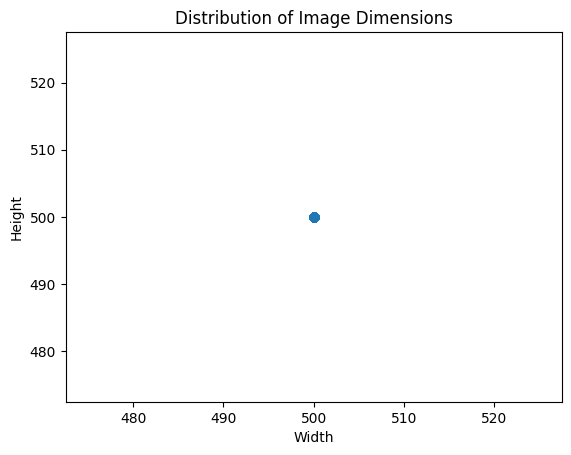

In [31]:
#Distribuição das Dimensões de Altura e Largura das Imagens

plt.scatter(df['width'], df['height'])
plt.xlabel('Width')
plt.ylabel('Height')
plt.title('Distribution of Image Dimensions')
plt.show()

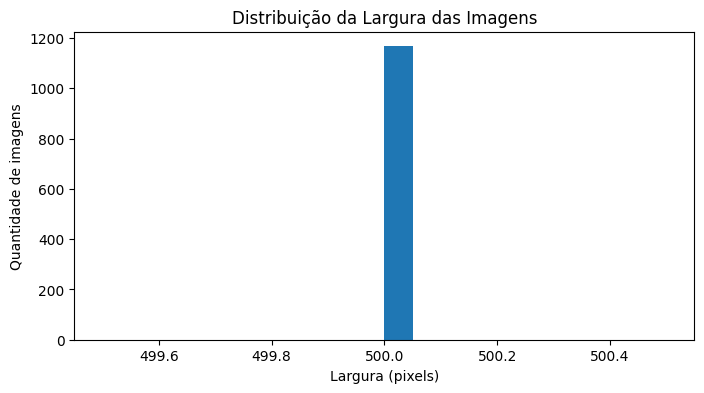

In [32]:
# Histograma da Largura
plt.figure(figsize=(8,4))
plt.hist(df['width'], bins=20)
plt.xlabel('Largura (pixels)')
plt.ylabel('Quantidade de imagens')
plt.title('Distribuição da Largura das Imagens')
plt.show()

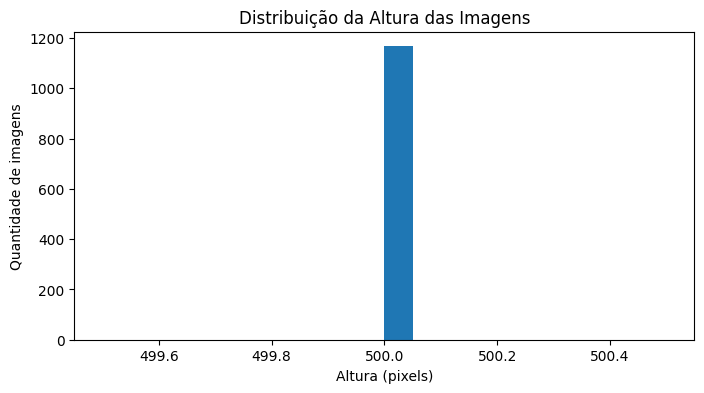

In [33]:
# Histograma da altura
plt.figure(figsize=(8,4))
plt.hist(df['height'], bins=20)
plt.xlabel('Altura (pixels)')
plt.ylabel('Quantidade de imagens')
plt.title('Distribuição da Altura das Imagens')
plt.show()

In [34]:
dimensoes = (
    df.groupby(['width', 'height'])
      .size()
      .reset_index(name='quantidade')
)

print(dimensoes)

   width  height  quantidade
0    500     500        1167


In [35]:
print(df.columns)

Index(['image_path', 'corrupted', 'image_hash', 'image_format', 'width',
       'height', 'channels', 'label'],
      dtype='object')


In [36]:
#Quantidade de informações nulas
df.isnull().sum()

,0
image_path,0
corrupted,0
image_hash,0
image_format,0
width,0
height,0
channels,0
label,0


### Qualidade das Imagens

In [37]:
#Total de imagens corrompidas

df['corrupted'].sum()

np.int64(0)

In [38]:
#Quantidade de imagens corrompidas e não corrompidas

df['corrupted'].value_counts()

,count
corrupted,
False,1167


### Distribuição das Classes

In [39]:
import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração visual dos gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 5]

In [40]:
from pathlib import Path
import pandas as pd

# Caminho apontando para a pasta que você mostrou na imagem
pastas = {
    "Treinamento": "/content/drive/MyDrive/bean-leaf-lesions-classification/train",
    "Validação": "/content/drive/MyDrive/bean-leaf-lesions-classification/val",
    "Teste": "/content/drive/MyDrive/bean-leaf-lesions-classification/test"
}


# Extensões de imagem comuns
valid_extensions = {".jpg", ".jpeg", ".png", ".bmp"}

data = []

# Varre todos os arquivos dentro da pasta archive
for split_name, folder_path_str in pastas.items():
    folder_path = Path(folder_path_str)
    for file_path in folder_path.rglob("*"):
        if file_path.is_file() and file_path.suffix.lower() in valid_extensions:
            # Captura o caminho relativo a partir do diretório base (por exemplo, train, val, test)
            # A estrutura esperada agora é: base_folder/classe/imagem.jpg
            relative_to_base = file_path.relative_to(folder_path)

            # A label é o nome da pasta da classe
            label = relative_to_base.parent.name

            data.append({"Split": split_name, "Classe": label})

# Criar o DataFrame principal
df_images = pd.DataFrame(data)

if df_images.empty:
    print("Nenhuma imagem encontrada. Verifique os caminhos e a estrutura das pastas.")
else:
    print(f"Total de imagens encontradas: {len(df_images)}")

Total de imagens encontradas: 1167


In [41]:
# Agrupa por classe e split (se houver) para contar
if df_images['Split'].nunique() > 1:
    df_dist = df_images.groupby(['Split', 'Classe']).size().reset_index(name='Quantidade')
    df_dist['Porcentagem (%)'] = (df_dist['Quantidade'] / df_dist.groupby('Split')['Quantidade'].transform('sum')) * 100
else:
    df_dist = df_images.groupby('Classe').size().reset_index(name='Quantidade')
    df_dist['Porcentagem (%)'] = (df_dist['Quantidade'] / df_dist['Quantidade'].sum()) * 100

# Exibir a tabela formatada
print("\n         Tabela de Distribuição de Classes")
print(df_dist.to_string(index=False, formatters={'Porcentagem (%)': '{:.2f}%'.format}))


         Tabela de Distribuição de Classes
      Split            Classe  Quantidade Porcentagem (%)
      Teste angular_leaf_spot          49          31.82%
      Teste         bean_rust          55          35.71%
      Teste           healthy          50          32.47%
Treinamento angular_leaf_spot         296          33.64%
Treinamento         bean_rust         293          33.30%
Treinamento           healthy         291          33.07%
  Validação angular_leaf_spot          44          33.08%
  Validação         bean_rust          45          33.83%
  Validação           healthy          44          33.08%


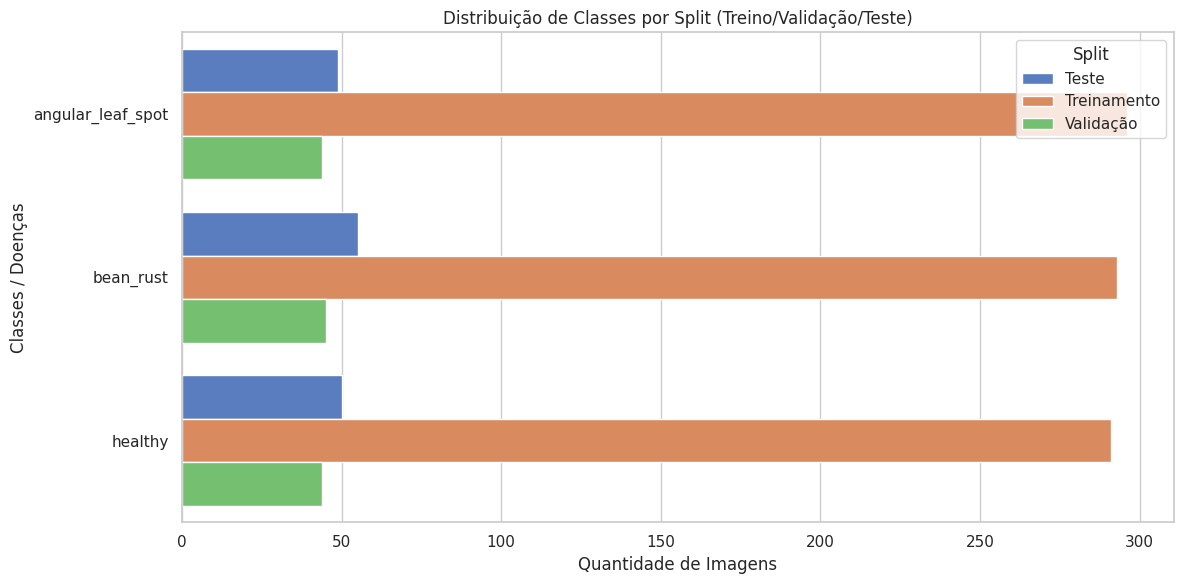

In [42]:
# Plotar o gráfico dependendo da estrutura encontrada
plt.figure(figsize=(12, 6))

if df_images['Split'].nunique() > 1:
    # Gráfico comparativo se houver divisões de treino/validação/teste
    sns.barplot(x='Quantidade', y='Classe', hue='Split', data=df_dist, palette='muted')
    plt.title('Distribuição de Classes por Split (Treino/Validação/Teste)')
else:
    # Gráfico simples
    sns.barplot(x='Quantidade', y='Classe', data=df_dist.sort_values('Quantidade', ascending=False), palette='viridis')
    plt.title('Distribuição Geral de Classes - Lesões de Folhas de Feijão')

plt.xlabel('Quantidade de Imagens')
plt.ylabel('Classes / Doenças')
plt.tight_layout()
plt.show()

## Insights

- As três classes (angular_leaf_spot, bean_rust e healthy) estão distribuídas de forma praticamente idêntica, representando aproximadamente entre 31% e 34% do dataset cada uma. Não é preciso se preocupar com o balanceamento de dados, o modelo tem a quantidade de exemplos necessária para saber o que é uma folha saudável e o que é cada tipo de doença.

-  A Acurácia nesse projeto vai ser uma métrica extremamente confiável devido a natureza balanceada apresentada nesse dataset.



# Resumo

## O que o código faz (Passo a Passo):
- Configuração do Ambiente: Importa as bibliotecas necessárias para manipulação de arquivos (pathlib), modelagem de dados (pandas) e plotagem gráfica (matplotlib e seaborn), definindo um tema visual padronizado.

- Mapeamento Dinâmico de Arquivos: Varre a pasta alvo (archive) filtrando apenas extensões de imagem válidas (.jpg, .jpeg, .png, .bmp). Ele analisa a estrutura de pastas para extrair automaticamente o Split (Treino/Validação/Teste) e a Classe (tipo de doença ou folha saudável), organizando tudo em um DataFrame do Pandas.

- Análise Estatística da Distribuição: Agrupa os dados para calcular a quantidade absoluta de imagens e a porcentagem que cada classe representa dentro de seu respectivo split, exibindo uma tabela formatada no console.

- Visualização Gráfica: Gera um gráfico de barras horizontal comparativo utilizando o seaborn. O gráfico ilustra visualmente a distribuição das classes por split, facilitando a verificação de um possível desbalanceamento de dados.

### Duplicatas

In [43]:
import hashlib
import os
from pathlib import Path
import pandas as pd

# Caminho apontando para a pasta que você mostrou na imagem
pastas = {
     "/content/drive/MyDrive/bean-leaf-lesions-classification"
    }


In [44]:
# Buscar arquivos CSV ou JSON no diretório
metadata_files = []
for path_str in pastas:
    folder_path = Path(path_str)
    metadata_files.extend(list(folder_path.rglob("*.csv")))
    metadata_files.extend(list(folder_path.rglob("*.json")))

if metadata_files:
    print(f" Encontrado(s) {len(metadata_files)} arquivo(s) de metadados:")
    for meta_path in metadata_files:
        print(f"\n--- Analisando: {meta_path.name} ---")
        if meta_path.suffix == '.csv':
            df_meta = pd.read_csv(meta_path)
        else:
            df_meta = pd.read_json(meta_path)

        # Total de linhas vs Linhas únicas
        total_rows = len(df_meta)
        duplicated_rows = df_meta.duplicated().sum()

        print(f"Total de registros: {total_rows}")
        print(f"Linhas exatamente duplicadas: {duplicated_rows}")

        if duplicated_rows > 0:
            print(" Exemplo de linhas duplicadas:")
            print(df_meta[df_meta.duplicated(keep=False)].head())
else:
    print(" Nenhum arquivo CSV/JSON de metadados encontrado na pasta. Prosseguindo para a verificação das imagens...")

 Encontrado(s) 3 arquivo(s) de metadados:

--- Analisando: train.csv ---
Total de registros: 1034
Linhas exatamente duplicadas: 0

--- Analisando: val.csv ---
Total de registros: 133
Linhas exatamente duplicadas: 0

--- Analisando: test.csv ---
Total de registros: 154
Linhas exatamente duplicadas: 0


In [45]:
def calculate_md5(file_path, chunk_size=8192):
    """Calcula o hash MD5 de um arquivo lendo em partes (eficiente em memória)."""
    hasher = hashlib.md5()
    with open(file_path, 'rb') as f:
        while chunk := f.read(chunk_size):
            hasher.update(chunk)
    return hasher.hexdigest()
valid_extensions = {".jpg", ".jpeg", ".png", ".bmp"}
image_records = []

print(" Mapeando e gerando hashes de todas as imagens...")

for path_str in pastas:
    base_folder_path = Path(path_str)
    for file_path in base_folder_path.rglob("*"):
        if file_path.is_file() and file_path.suffix.lower() in valid_extensions:
            # Determine the relative path to extract split and label
            # We need to reconstruct the relative path from the *first* folder after the base_folder_path
            # For example, if base_folder_path is 'train' and file_path is 'train/healthy/image.jpg'
            # relative_parts should start from 'healthy'

            relative_to_base = file_path.relative_to(base_folder_path)
            parts = relative_to_base.parts

            # Assuming structure: base_folder_path/classe/imagem.jpg
            # If there's only one part, it means it's directly in the base_folder_path, which is unlikely for class labels
            if len(parts) >= 1:
                label = parts[0] # The first subfolder is typically the class
            else:
                label = "unknown" # Fallback if no class folder is found

            # In this context, 'pastas' holds only training data, so 'split' can be hardcoded or inferred if structure allows.
            # For now, let's assume if it's in 'train', split is 'Treinamento'.
            split = "Treinamento" # Adjust if 'pastas' can contain other splits

            # Generates the MD5 hash of the image content
            file_hash = calculate_md5(file_path)

            image_records.append({
                "filename": file_path.name,
                "path": str(file_path),
                "split": split,
                "classe": label,
                "hash_md5": file_hash
            })

df_hashes = pd.DataFrame(image_records)
print(f" Concluído! {len(df_hashes)} imagens processadas.")

 Mapeando e gerando hashes de todas as imagens...
 Concluído! 1167 imagens processadas.


In [46]:
# Identificar hashes que aparecem mais de uma vez
duplicate_hashes = df_hashes[df_hashes.duplicated(subset=['hash_md5'], keep=False)]

if duplicate_hashes.empty:
    print("NENHUMA DUPLICATA ENCONTRADA! O dataset está 100% limpo quanto a conteúdos idênticos.")
else:
    total_duplicadas = duplicate_hashes['hash_md5'].nunique()
    print(f"Foram encontradas imagens duplicadas associadas a {total_duplicadas} hashes diferentes.\n")

    # 1. Checar se há VAZAMENTO DE DADOS (Data Leakage) entre Train e Val
    leakage_df = duplicate_hashes.groupby('hash_md5')['split'].nunique()
    hashes_vazados = leakage_df[leakage_df > 1].index

    if len(hashes_vazados) > 0:
        print(f"ALERTA CRÍTICO DE DATA LEAKAGE!")
        print(f"Existem {len(hashes_vazados)} imagem(ns) idêntica(s) presentes TANTO no Treino QUANTO na Validação.\n")
        print("Exemplos de imagens com vazamento:")
        display(duplicate_hashes[duplicate_hashes['hash_md5'].isin(hashes_vazados)][['filename', 'split', 'classe', 'hash_md5']].head(10))
    else:
        print("Sem Data Leakage: As duplicatas existem, mas não estão cruzando a fronteira de treino/validação.")

    # 2. Exibir tabela resumo de todas as duplicatas
    print("\n--- Tabela Completa de Arquivos Duplicados ---")
    display(duplicate_hashes.sort_values(by='hash_md5')[['filename', 'split', 'classe', 'hash_md5']])

NENHUMA DUPLICATA ENCONTRADA! O dataset está 100% limpo quanto a conteúdos idênticos.


### Informações complementares
Elaborar uma apresentação para mostrar os resultados.

Apresentar o dataset de forma detalhada.

Verifique quais itens em Informações esperadas podem ser aplicados no dataset.

### ATIVIDADE-04-ETAPA-02

#### Objetivo: Apresentar métodos da literatura e propor ideias para métodos próprios.



### Métodos da literatura

#### Notebooks executados

https://www.kaggle.com/code/akhilchibber/bean-leaf-lesions-classification#The-Dataset

 https://www.kaggle.com/code/marquis03/resnet-18-bean-leaf-lesions-classification

### Métodos próprios

#### Apresentar ideias que podem melhorar os métodos encontrados e testados da literatura.

- O notebook analisado não realizou a separação das imagens para teste, portanto sugerimos a separação de uma parte das imagens de treinamento como melhoria;

- O notebook não realizou a análise exploratória dos dados, portanto, a imagem corrompida não foi excluída do dataset;



#### Ideias para melhorar uma técnica

Otimização de Hiperparâmetros - alterar ou reduzir os hiperparâmetros.

Elaborar uma nova arquitetura mais leve para que o treino e o teste sejam rápidos.

Reduzir número de imagens no treinamento e manter o desempenho.

### Informações complementares

Elaborar uma apresentação para mostrar os métodos da literatura e próprios.

### **COMPARAÇÃO COM O MÉTODO EFFICIENT NET**

#### Transformação e aumento das imagens

Usaremos as transformações (transforms) do PyTorch para realizar o pré-processamento e o aumento (data augmentation) das imagens. Essa etapa é fundamental para que os modelos de deep learning consigam generalizar melhor.

In [47]:
# Data Transformation and Augmentation
import torchvision.transforms as transforms

# Define transformations
train_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    # Other transformations can be added here
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

#### Criar um Dataset Personalizado



Criamos uma classe de dataset personalizada que estende a classe Dataset do PyTorch. Essa classe será responsável por carregar as imagens e aplicar as transformações.

In [48]:
from torch.utils.data import Dataset
from PIL import Image
import os

class BeanLeafDataset(Dataset):

    def __init__(self, root_dir, transform=None):

        self.root_dir = root_dir
        self.transform = transform

        # Classes
        self.classes = sorted([
            classe
            for classe in os.listdir(root_dir)
            if os.path.isdir(
                os.path.join(root_dir, classe)
            )
        ])

        # classe -> número
        self.class_to_idx = {
            classe: idx
            for idx, classe in enumerate(self.classes)
        }

        self.images = []

        # Percorrer cada classe
        for classe in self.classes:

            pasta_classe = os.path.join(
                root_dir,
                classe
            )

            for arquivo in os.listdir(pasta_classe):

                caminho = os.path.join(
                    pasta_classe,
                    arquivo
                )

                if os.path.isfile(caminho):

                    self.images.append(
                        (
                            caminho,
                            self.class_to_idx[classe]
                        )
                    )

    def __len__(self):
        return len(self.images)

    def __getitem__(self, index):

        caminho, label = self.images[index]

        imagem = Image.open(
            caminho
        ).convert("RGB")

        if self.transform:
            imagem = self.transform(imagem)

        return imagem, label

In [49]:
from torchvision import transforms

train_transform = transforms.Compose([

    transforms.Resize((224, 224)),

    transforms.RandomHorizontalFlip(p=0.5),

    transforms.RandomRotation(15),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


val_test_transform = transforms.Compose([

    transforms.Resize((224, 224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

#### Criar os datasets sem CSV

In [50]:
root_dir = "/content/drive/MyDrive/bean-leaf-lesions-classification"

train_dataset = BeanLeafDataset(
    root_dir=os.path.join(root_dir, "train"),
    transform=train_transform
)

val_dataset = BeanLeafDataset(
    root_dir=os.path.join(root_dir, "val"),
    transform=val_test_transform
)

test_dataset = BeanLeafDataset(
    root_dir=os.path.join(root_dir, "test"),
    transform=val_test_transform
)

#### Confira as classes

In [51]:
print("Classes:", train_dataset.classes)
print("Mapeamento:", train_dataset.class_to_idx)

Classes: ['angular_leaf_spot', 'bean_rust', 'healthy']
Mapeamento: {'angular_leaf_spot': 0, 'bean_rust': 1, 'healthy': 2}


#### Criar DataLoaders



Por fim, configuramos os DataLoaders do PyTorch para os conjuntos de dados de treinamento e validação. Os DataLoaders permitem o carregamento eficiente dos dados e sua divisão em lotes (batches) durante o treinamento.

In [52]:
from torch.utils.data import DataLoader

BATCH_SIZE = 25

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

#### Checagem do dataset

In [53]:
print("Classes:", train_dataset.classes)
print("Mapeamento:", train_dataset.class_to_idx)

print("Treinamento:", len(train_dataset))
print("Validação:", len(val_dataset))
print("Teste:", len(test_dataset))

Classes: ['angular_leaf_spot', 'bean_rust', 'healthy']
Mapeamento: {'angular_leaf_spot': 0, 'bean_rust': 1, 'healthy': 2}
Treinamento: 880
Validação: 133
Teste: 154


In [54]:
images, labels = next(iter(train_loader))

print("Formato das imagens:", images.shape)
print("Formato dos labels:", labels.shape)
print("Labels:", labels[:10])

Formato das imagens: torch.Size([25, 3, 224, 224])
Formato dos labels: torch.Size([25])
Labels: tensor([0, 0, 0, 2, 2, 2, 1, 1, 0, 1])


Isso conclui a etapa de Preparação dos Dados. Em seguida, passaremos para a etapa de construção do modelo.

#### **Construção do Modelo**



Nesta seção, vamos nos concentrar na configuração do modelo de deep learning. Ela abordará a parte do script em que o modelo de rede neural é carregado, utilizando os modelos pré-treinados do PyTorch, e posteriormente modificado para a tarefa específica de classificação.

Isso inclui a criação da classe MyDataset e a modificação da camada classificadora do modelo.

#### Importar as Bibliotecas Necessárias


Primeiro, precisamos importar os componentes necessários do PyTorch.

In [55]:
import torch
import torch.nn as nn
from torchvision import models

#### Definir o Modelo

Usaremos um modelo pré-treinado e modificaremos sua camada final para adequá-lo à nossa tarefa de classificação, que possui três classes:

healthy — saudável

angular_leaf_spot — mancha-angular da folha

bean_rust — ferrugem do feijoeiro

In [56]:
# Define the number of classes
num_classes = 3

# Load a pre-trained model
model = models.efficientnet_v2_s(pretrained=True)

# Modify the classifier
model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)

# Print the Deep Learning model architecture
print(model)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_V2_S_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_V2_S_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/efficientnet_v2_s-dd5fe13b.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_v2_s-dd5fe13b.pth


100%|██████████| 82.7M/82.7M [00:00<00:00, 222MB/s]


EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 24, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): FusedMBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
            (1): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
        )
        (stochastic_depth): StochasticDepth(p=0.0, mode=row)
      )
      (1): FusedMBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
            (1): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  

#### Definir o Dispositivo

Precisamos definir o dispositivo como CPU ou GPU (caso esteja disponível) para realizar o treinamento do modelo.

In [57]:
# Set the device to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Move the model to the chosen device
model = model.to(device)

#### Imprimir o Resumo do Modelo


In [58]:
!pip install torchsummary

Isso conclui a etapa de construção do modelo. Carregamos com sucesso um modelo EfficientNet pré-treinado e o adaptamos para nossa tarefa de classificação em três classes.

O modelo agora está pronto para ser treinado com o nosso conjunto de dados de lesões em folhas de feijão.

#### **Treinamento e Validação do Modelo**

Esta etapa abrangerá o loop de treinamento e as funções necessárias para o treinamento (train) e a validação (val).

Serão detalhadas as etapas do processo de treinamento, incluindo a configuração da função de perda (loss function), do otimizador (optimizer), do agendador da taxa de aprendizado (learning rate scheduler) e do próprio loop de treinamento, que inclui o mecanismo de early stopping (parada antecipada).

#### Importar as Bibliotecas Necessárias

Primeiro, precisamos garantir que todas as bibliotecas necessárias estejam importadas.

In [59]:
from torchsummary import summary

# Print the model summary (for input size [3, 224, 224])
summary(model, input_size=(3, 224, 224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 24, 112, 112]             648
       BatchNorm2d-2         [-1, 24, 112, 112]              48
              SiLU-3         [-1, 24, 112, 112]               0
            Conv2d-4         [-1, 24, 112, 112]           5,184
       BatchNorm2d-5         [-1, 24, 112, 112]              48
              SiLU-6         [-1, 24, 112, 112]               0
   StochasticDepth-7         [-1, 24, 112, 112]               0
       FusedMBConv-8         [-1, 24, 112, 112]               0
            Conv2d-9         [-1, 24, 112, 112]           5,184
      BatchNorm2d-10         [-1, 24, 112, 112]              48
             SiLU-11         [-1, 24, 112, 112]               0
  StochasticDepth-12         [-1, 24, 112, 112]               0
      FusedMBConv-13         [-1, 24, 112, 112]               0
           Conv2d-14           [-1, 96,

In [60]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
from tqdm import tqdm

# Hiperparâmetros de treinamento


In [61]:
# Loss function
criterion = nn.CrossEntropyLoss()

# Optimizer (using AdamW here)
optimizer = optim.AdamW(model.parameters(), lr=0.0001)

# Learning rate scheduler (optional)
lr_scheduler = lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

#### Funções de Treinamento e Validação

Definimos as funções responsáveis pelo treinamento e pela validação do modelo.

In [62]:
def train_model(model, criterion, optimizer, scheduler, num_epochs=25):
    train_loss_history = []
    train_acc_history = []
    val_loss_history = []
    val_acc_history = []

    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 10)

        # Each epoch has a training and validation phase
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()  # Set model to training mode
                dataloader = train_loader
            else:
                model.eval()   # Set model to evaluate mode
                dataloader = val_loader

            running_loss = 0.0
            running_corrects = 0

            # Iterate over data
            for inputs, labels in dataloader:
                inputs = inputs.to(device)
                labels = labels.to(device).long()

                # Zero the parameter gradients
                optimizer.zero_grad()

                # Forward pass
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    # Backward + optimize only if in training phase
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                # Statistics
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            if phase == 'train':
                scheduler.step()

            epoch_loss = running_loss / len(dataloader.dataset)
            epoch_acc = running_corrects.double() / len(dataloader.dataset)

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            # Save the metrics as Python numbers
            if phase == 'train':
                train_loss_history.append(epoch_loss)
                train_acc_history.append(epoch_acc.item())  # Convert to Python number
            else:
                val_loss_history.append(epoch_loss)
                val_acc_history.append(epoch_acc.item())  # Convert to Python number

    print('Training complete')

    return model, train_loss_history, train_acc_history, val_loss_history, val_acc_history

#### Treinar o Modelo

Agora, utilizamos as funções definidas anteriormente para treinar e validar o nosso modelo. Definimos o número de épocas (epochs) de acordo com a necessidade do treinamento.

In [63]:
model, train_loss_history, train_acc_history, val_loss_history, val_acc_history = train_model(model, criterion, optimizer, lr_scheduler, num_epochs=25)

Epoch 1/25
----------
train Loss: 0.7542 Acc: 0.7091
val Loss: 0.2836 Acc: 0.9398
Epoch 2/25
----------
train Loss: 0.2162 Acc: 0.9386
val Loss: 0.1639 Acc: 0.9248
Epoch 3/25
----------
train Loss: 0.1103 Acc: 0.9693
val Loss: 0.0776 Acc: 0.9850
Epoch 4/25
----------
train Loss: 0.0599 Acc: 0.9852
val Loss: 0.0670 Acc: 0.9850
Epoch 5/25
----------
train Loss: 0.0492 Acc: 0.9830
val Loss: 0.1244 Acc: 0.9474
Epoch 6/25
----------
train Loss: 0.0454 Acc: 0.9875
val Loss: 0.0713 Acc: 0.9624
Epoch 7/25
----------
train Loss: 0.0252 Acc: 0.9966
val Loss: 0.0859 Acc: 0.9624
Epoch 8/25
----------
train Loss: 0.0276 Acc: 0.9932
val Loss: 0.0462 Acc: 0.9850
Epoch 9/25
----------
train Loss: 0.0227 Acc: 0.9955
val Loss: 0.0732 Acc: 0.9699
Epoch 10/25
----------
train Loss: 0.0130 Acc: 1.0000
val Loss: 0.0623 Acc: 0.9699
Epoch 11/25
----------
train Loss: 0.0085 Acc: 0.9989
val Loss: 0.0758 Acc: 0.9699
Epoch 12/25
----------
train Loss: 0.0159 Acc: 0.9966
val Loss: 0.0539 Acc: 0.9774
Epoch 13/25
-

In [64]:
# Save the model
torch.save(model.state_dict(), "/content/drive/MyDrive/bean-leaf-lesions-classification/model.pth")

#### Plotagem das métricas

#### Após o treinamento, usaremos o Matplotlib para plotar, em um gráfico, a perda (loss) e a acurácia (accuracy) durante o treinamento do modelo.

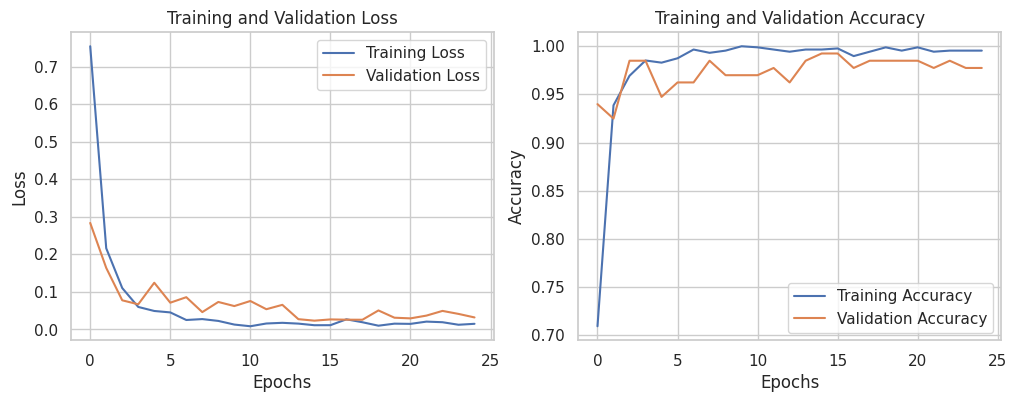

In [65]:
import matplotlib.pyplot as plt

# Plotting training and validation loss
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_loss_history, label='Training Loss')
plt.plot(val_loss_history, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Plotting training and validation accuracy
plt.subplot(1, 2, 2)
plt.plot(train_acc_history, label='Training Accuracy')
plt.plot(val_acc_history, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

#### Avaliação do Modelo

Nesta etapa, vamos nos concentrar em carregar o melhor modelo e avaliar seu desempenho no conjunto de dados de validação.

Essa parte abordará as seções do script em que o modelo é carregado a partir do estado salvo (best.pth) e seu desempenho é avaliado utilizando o conjunto de dados de validação.

In [66]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns

def evaluate_model(model, dataloader):
    model.eval()  # Set the model to evaluation mode
    all_preds = []
    all_labels = []

    with torch.no_grad():  # No need to track the gradients
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return all_labels, all_preds

# Evaluate the model
all_labels, all_preds = evaluate_model(model, val_loader)

#### Relatório de Classificação e Acurácia

#### Geraremos um relatório de classificação (classification report) e calcularemos a acurácia (accuracy) do modelo.

In [67]:
print("Classification Report:")
print(classification_report(all_labels, all_preds, target_names=["healthy", "angular_leaf_spot", "bean_rust"]))

accuracy = accuracy_score(all_labels, all_preds)
print(f"Accuracy: {accuracy * 100:.2f}%")

Classification Report:
                   precision    recall  f1-score   support

          healthy       1.00      0.95      0.98        44
angular_leaf_spot       0.96      0.98      0.97        45
        bean_rust       0.98      1.00      0.99        44

         accuracy                           0.98       133
        macro avg       0.98      0.98      0.98       133
     weighted avg       0.98      0.98      0.98       133

Accuracy: 97.74%


# Matriz de confusão

Explicação: Este código avalia um modelo de classificação em um conjunto de teste, armazenando rótulos verdadeiros e previsões. Ele gera um relatório de classificação e visualiza a matriz de confusão, mostrando o desempenho do modelo em termos de acurácia e outras métricas.

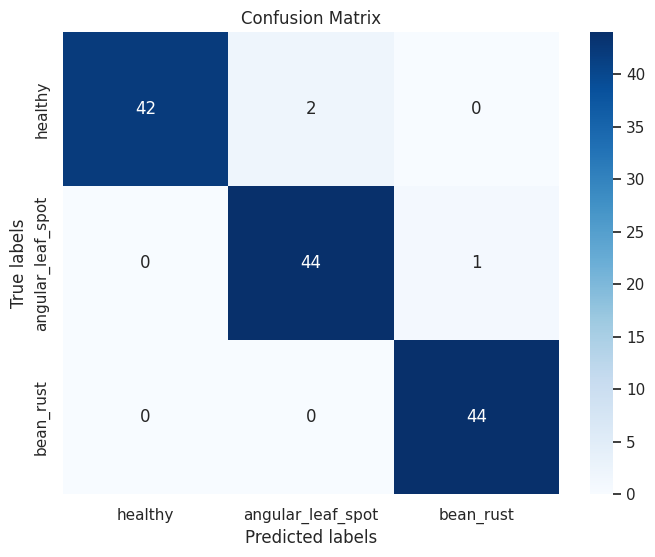

In [68]:
# Generate a confusion matrix
conf_matrix = confusion_matrix(all_labels, all_preds)

# Plotting the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='g', cmap='Blues', xticklabels=["healthy", "angular_leaf_spot", "bean_rust"], yticklabels=["healthy", "angular_leaf_spot", "bean_rust"])
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix')
plt.show()

# Inspeção Visual

Explicação: O código à seguir visualiza as previsões de um modelo em um conjunto de teste, mostrando 9 imagens em uma grade. Cada imagem é acompanhada de sua previsão, a probabilidade da previsão e o rótulo verdadeiro. Isso ajuda a entender como o modelo está se comportando em relação às classes reais.

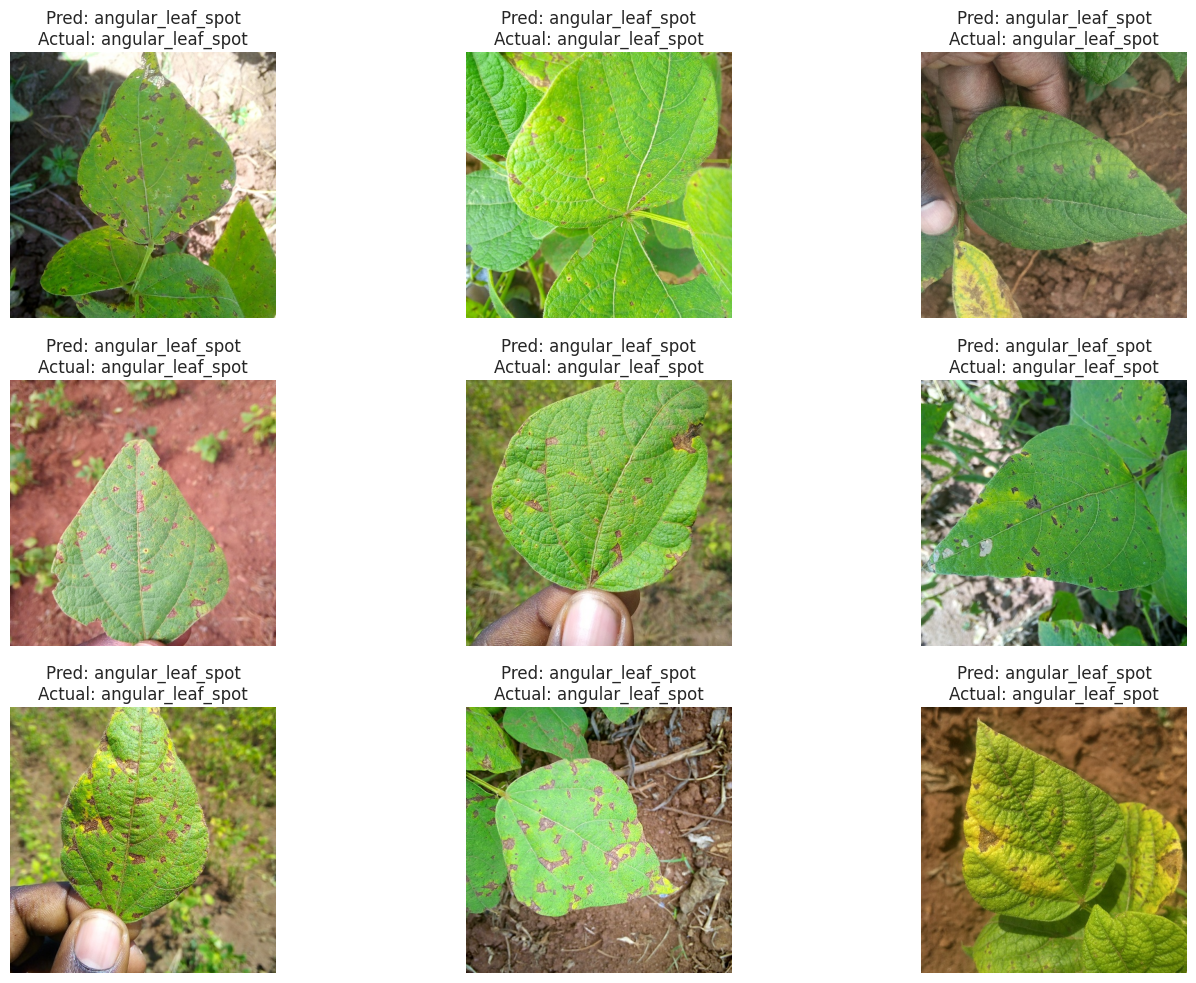

In [69]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

# Classes utilizadas pelo Dataset
classes = test_dataset.classes

# Converter índices das classes para seus nomes
pred_labels = [
    classes[pred]
    for pred in all_preds
]

truth_labels = [
    classes[label]
    for label in all_labels
]

# Índice inicial
index = 0

# Criar figura com 3x3 imagens
fig, axes = plt.subplots(
    nrows=3,
    ncols=3,
    figsize=(15, 10)
)

for i in range(3):

    for j in range(3):

        # Caminho da imagem
        image_path = test_dataset.images[index][0]

        # Carregar imagem
        imagem = cv2.imread(image_path)

        # Converter BGR para RGB
        imagem_rgb = cv2.cvtColor(
            imagem,
            cv2.COLOR_BGR2RGB
        )

        # Mostrar imagem
        axes[i][j].imshow(imagem_rgb)

        # Título
        axes[i][j].set_title(
            f"Pred: {pred_labels[index]}\n"
            f"Actual: {truth_labels[index]}"
        )

        axes[i][j].axis("off")

        index += 1

plt.tight_layout()
plt.show()

### Visualização de Exemplos Mal Classificados

Foram encontrados 3 exemplos mal classificados.


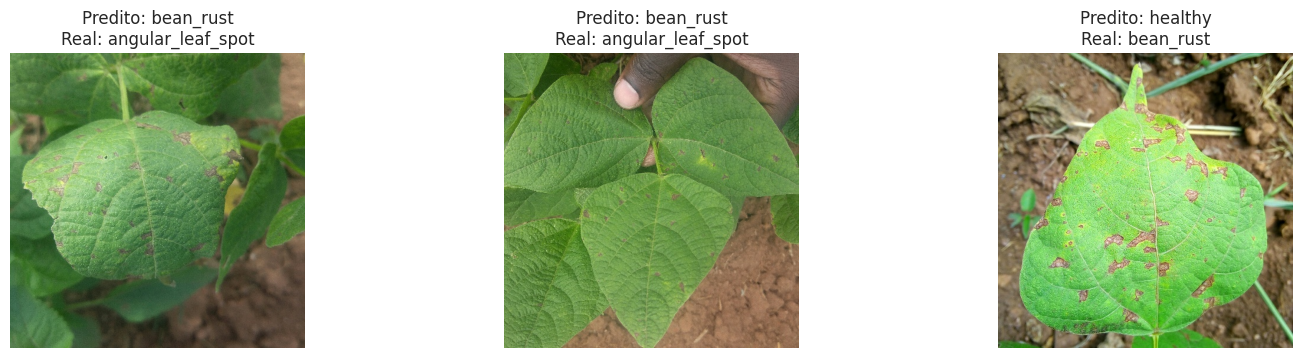

In [70]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

# Converter para arrays
all_preds_array = np.array(all_preds)
all_labels_array = np.array(all_labels)

# Encontrar somente as imagens classificadas incorretamente
misclassified_indices = np.where(
    all_preds_array != all_labels_array
)[0]

# Verificar se existem erros
if len(misclassified_indices) == 0:

    print(
        "Nenhum exemplo mal classificado "
        "encontrado no conjunto de teste!"
    )

else:

    print(
        f"Foram encontrados "
        f"{len(misclassified_indices)} "
        f"exemplos mal classificados."
    )

    # Se houver menos de 9, mostra todos
    if len(misclassified_indices) <= 9:

        display_indices = misclassified_indices

    else:

        # Seleciona 9 aleatoriamente
        display_indices = np.random.choice(
            misclassified_indices,
            9,
            replace=False
        )

    # Criar figura
    fig, axes = plt.subplots(
        nrows=3,
        ncols=3,
        figsize=(15, 10)
    )

    axes = axes.flatten()

    # Classes do Dataset
    classes = test_dataset.classes

    # Exibir imagens
    for i, idx in enumerate(display_indices):

        # Caminho da imagem
        image_path = test_dataset.images[idx][0]

        # Carregar imagem
        img = cv2.imread(image_path)

        # Verificar se foi carregada
        if img is None:
            print(
                f"Não foi possível carregar: "
                f"{image_path}"
            )
            continue

        # BGR → RGB
        img = cv2.cvtColor(
            img,
            cv2.COLOR_BGR2RGB
        )

        # Classe prevista
        pred_label = classes[
            all_preds_array[idx]
        ]

        # Classe verdadeira
        true_label = classes[
            all_labels_array[idx]
        ]

        # Mostrar imagem
        axes[i].imshow(img)

        axes[i].set_title(
            f"Predito: {pred_label}\n"
            f"Real: {true_label}"
        )

        axes[i].axis("off")

    # Esconder espaços vazios
    for j in range(
        len(display_indices),
        len(axes)
    ):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

### Conclusões

A acurácia no modelo EfficientNet é de 97.74%, no modelo ResNet-50 a acurácia é de 93.51%. Porém a taxa de aprendizado no modelo EfficientNet é LR 0,0001 enquanto no ResNet-50 é de 0,1.

O modelo apresentou excelente desempenho na classificação das imagens, alcançando uma acurácia de 97,74%.

Das 133 imagens avaliadas, 130 foram classificadas corretamente.

As métricas de precision, recall e F1-score permaneceram acima de 95% em todas as classes, indicando uma boa capacidade de generalização e equilíbrio entre as categorias.

A classe bean_rust apresentou o melhor desempenho, com recall de 100% e F1-score de 99%.

A principal fonte de erro ocorreu na classe healthy, em que duas imagens foram classificadas como angular_leaf_spot.

De forma geral, os resultados indicam que o modelo possui excelente capacidade de distinguir folhas saudáveis de folhas afetadas por mancha-angular e ferrugem.

